clase 06/05/2026

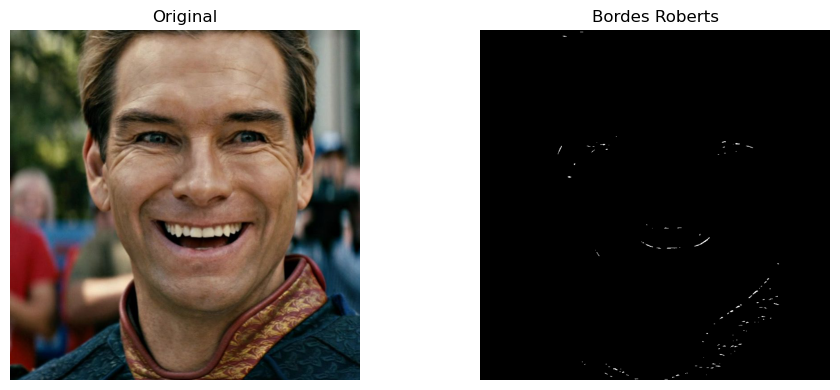

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def filtro_roberts_mejorado(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    suavizar = cv2.GaussianBlur(img_gris, (3, 3), 0)
    robertx = np.array([[-1, 0], [0, 1]], dtype=np.float32)
    roberty = np.array([[0, -1], [1, 0]], dtype=np.float32)
    r_x = cv2.filter2D(suavizar, -1, robertx)
    r_y = cv2.filter2D(suavizar, -1, roberty)
    roberts = cv2.addWeighted(r_x, 0.5, r_y, 0.5, 0)
    _, bordes = cv2.threshold(roberts, 20, 255, cv2.THRESH_BINARY)
    return bordes


img = cv2.imread('bordeshome.jpg')

bordes = filtro_roberts_mejorado(img)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(bordes, cmap='gray')
plt.title('Bordes Roberts')
plt.axis('off')

plt.tight_layout()
plt.show()

prewitt mejorado

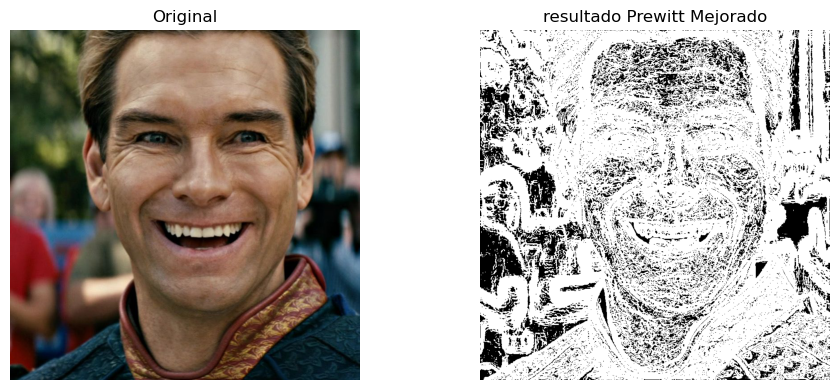

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def filtro_prewitt_mejorado(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    suavizar = cv2.GaussianBlur(img_gris, (3, 3), 0)
    kernel_x = np.array([[-3, 0, 3], [-3, 0, 3], [-3, 0, 3]], dtype=np.float32)
    kernel_y = np.array([[3, 3, 3], [0, 0, 0], [-3, -3, -3]], dtype=np.float32)
    grad_x = cv2.filter2D(suavizar, cv2.CV_64F, kernel_x)
    grad_y = cv2.filter2D(suavizar, cv2.CV_64F, kernel_y)
    magnitud = np.sqrt(grad_x**2 + grad_y**2)

    _,bordes = cv2.threshold(magnitud, 20, 255, cv2.THRESH_BINARY)
    return bordes


img = cv2.imread('bordeshome.jpg')

bordes = filtro_prewitt_mejorado(img)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(bordes, cmap='gray')
plt.title('resultado Prewitt Mejorado')
plt.axis('off')

plt.tight_layout()
plt.show()

sgt

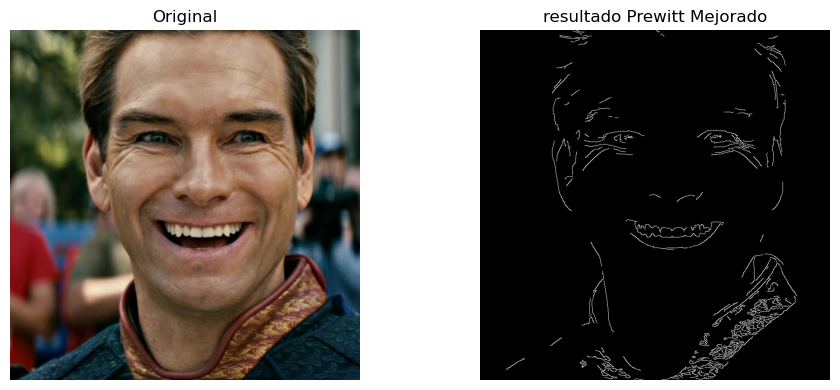

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_canny(img, umbral_bajo=100, umbral_alto=200):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    bordes = cv2.Canny(img_gris, umbral_bajo, umbral_alto)
    return bordes

img = cv2.imread('bordeshome.jpg')

bordes = filtro_canny(img)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(bordes, cmap='gray')
plt.title('resultado Prewitt Mejorado')
plt.axis('off')

plt.tight_layout()
plt.show()